Imports

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.covariance import LedoitWolf
import scipy.optimize as sco
import warnings
warnings.filterwarnings('ignore')

Step 1: Fetch adjusted close prices for 12 NSE stocks (2020-2025)

In [2]:
tickers = ['TCS.NS', 'INFY.NS', 'HCLTECH.NS', 'TATASTEEL.NS', 'HINDALCO.NS', 
           'JINDALSTEL.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'KOTAKBANK.NS', 
           'HINDUNILVR.NS', 'ITC.NS', 'NESTLEIND.NS']

print("Fetching data...")
data = yf.download(
    tickers, 
    start='2019-12-01', 
    end='2025-01-01', 
    interval='1mo',
    auto_adjust=True  # Use adjusted prices
)['Close']  # Use 'Close' instead of 'Adj Close'

# Remove any NaN rows and forward fill
data = data.dropna()
print(f"Data shape: {data.shape}")

# Calculate monthly returns
returns = data.pct_change().dropna()
print(f"Returns shape: {returns.shape}")

# Split: First 4 years (train), Last year (test)
train_returns = returns.iloc[:48]  # ~4 years monthly
test_returns = returns.iloc[48:]   # Last year

print(f"Train period: {train_returns.index[0]} to {train_returns.index[-1]}")
print(f"Train data shape: {train_returns.shape}")
print(f"Test period: {test_returns.index[0]} to {test_returns.index[-1]}")
print(f"Test data shape: {test_returns.shape}")

Fetching data...


[*********************100%***********************]  12 of 12 completed

Data shape: (61, 12)
Returns shape: (60, 12)
Train period: 2020-01-01 00:00:00 to 2023-12-01 00:00:00
Train data shape: (48, 12)
Test period: 2024-01-01 00:00:00 to 2024-12-01 00:00:00
Test data shape: (12, 12)


Step 2: Sample Covariance Matrix

In [3]:
sample_cov = train_returns.cov() * 12  # Annualized
print("\nSample Covariance Matrix shape:", sample_cov.shape)

# Condition Number (κ) - High value indicates ill-conditioning
kappa_sample = np.linalg.cond(sample_cov.values)
print("Condition Number (κ) of Sample Covariance:", format(kappa_sample, '.2f'))


Sample Covariance Matrix shape: (12, 12)
Condition Number (κ) of Sample Covariance: 97.87


Step 3: Ledoit-Wolf Shrinkage

In [4]:
lw = LedoitWolf().fit(train_returns)
lw_cov = pd.DataFrame(lw.covariance_ * 12, index=tickers, columns=tickers)  # Annualized
shrinkage = lw.shrinkage_
print(f"\nLedoit-Wolf Shrinkage intensity: {shrinkage:.4f}")

# Condition Number of shrunk covariance
kappa_lw = np.linalg.cond(lw_cov.values)
print(f"Condition Number (κ) of LW Covariance: {kappa_lw:.2f}")
print(f"Improvement factor: {kappa_sample/kappa_lw:.1f}x")


Ledoit-Wolf Shrinkage intensity: 0.1661
Condition Number (κ) of LW Covariance: 26.33
Improvement factor: 3.7x


Step 4: Maximum Sharpe Ratio Portfolios

In [18]:
RF_ANNUAL = 0.065
RF_MONTHLY = RF_ANNUAL / 12  # monthly rf

# def max_sharpe_weights(cov_matrix, returns_mean):
#     """Calculate Maximum Sharpe portfolio weights (unconstrained, monthly returns)"""
#     n = len(returns_mean)
    
#     def objective(w):
#         port_return = w @ returns_mean
#         port_vol = np.sqrt(w @ cov_matrix.values @ w)
#         return -(port_return - RF_MONTHLY) / port_vol  # excess return Sharpe
    
#     # Constraints: sum(w) = 1
#     constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    
#     # No bounds — unconstrained (allows short selling)
#     bounds = None
    
#     # Initial guess: equal weights
#     w0 = np.ones(n) / n
    
#     result = sco.minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=constraints)
    
#     if result.success:
#         return result.x
#     else:
#         print(f"Optimization failed: {result.message}")
#         return np.ones(n) / n

def max_sharpe_weights(cov_matrix, returns_mean):
    """Calculate Maximum Sharpe portfolio weights (unconstrained, monthly returns)"""
    n = len(returns_mean)
    
    def objective(w):
        port_return = w @ returns_mean
        port_vol = np.sqrt(w @ cov_matrix.values @ w)
        return -(port_return - RF_MONTHLY) / port_vol

    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

    best_result = None
    best_sharpe = -np.inf

    np.random.seed(42)
    for _ in range(50):
        # Random starting weights (can be negative for unconstrained)
        w0 = np.random.randn(n)
        w0 = w0 / w0.sum()  # normalize to sum to 1

        result = sco.minimize(
            objective, w0,
            method='SLSQP',
            bounds=None,
            constraints=constraints,
            options={'maxiter': 10000, 'ftol': 1e-12}
        )

        if result.success and (-result.fun) > best_sharpe:
            best_sharpe = -result.fun
            best_result = result

    if best_result is None:
        print("All restarts failed — returning equal weights")
        return np.ones(n) / n

    return best_result.x

# Expected returns — keep as monthly (do NOT annualize, stays consistent with monthly cov)
mu_train = train_returns.mean()

# Sample Covariance portfolio
w_sample = max_sharpe_weights(sample_cov, mu_train)

# Ledoit-Wolf portfolio
w_lw = max_sharpe_weights(lw_cov, mu_train)

Step 5: Visualizations

> Visualization 1:
- Figure 1: Portfolio Weights Comparison before & after regularization
- Figure 2: Covariance Matrix Comparison (3-panel heatmap)

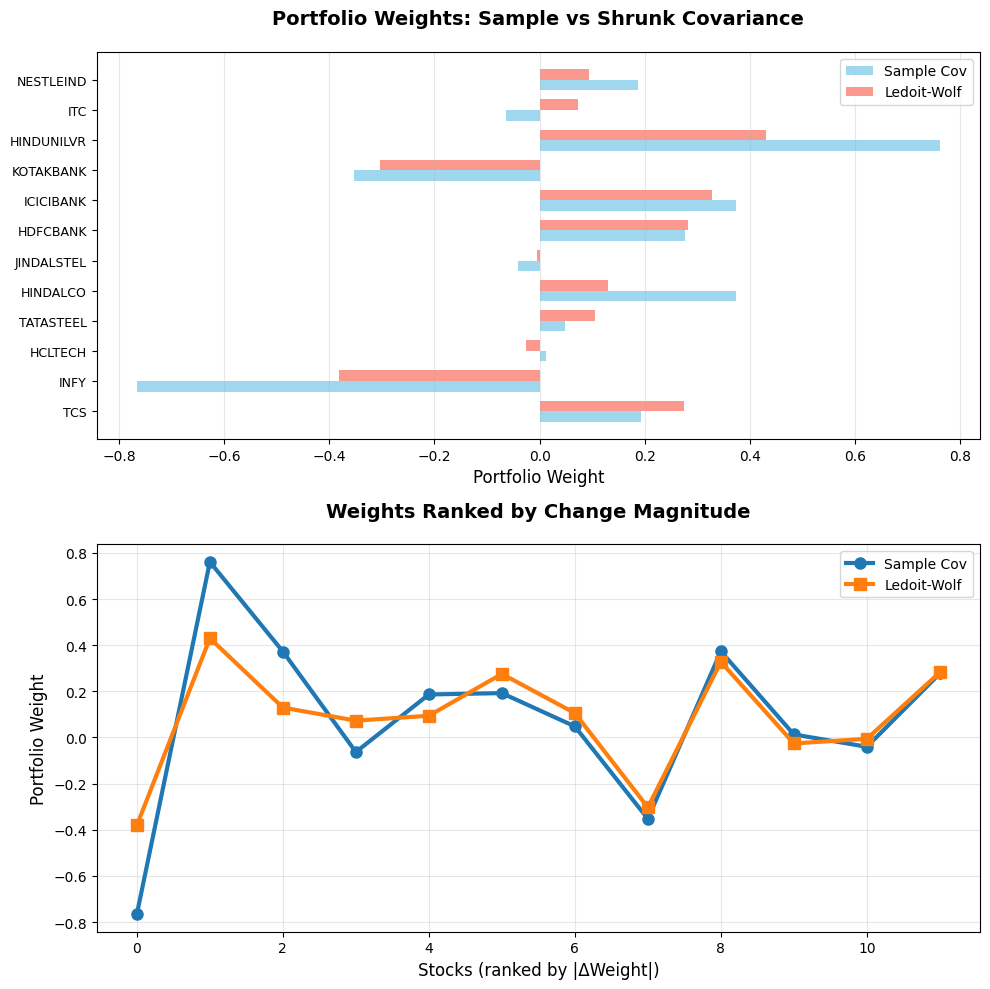

In [19]:
# Weights DataFrame (for reference)
weights_comparison = pd.DataFrame({
    'Sample_Cov': w_sample,
    'LedoitWolf': w_lw,
    'Abs_Diff': np.abs(w_sample - w_lw)
}, index=tickers)
weights_comparison.index = weights_comparison.index.str.replace('.NS', '')

# TWO PLOTS: 2x1 VERTICAL LAYOUT
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# 1. Portfolio Weights: Sample vs Shrunk Covariance (Horizontal Bar) - TOP
x_pos = np.arange(len(tickers))
width = 0.35
ax1.barh(x_pos - width/2, w_sample, width, label='Sample Cov', alpha=0.8, color='skyblue')
ax1.barh(x_pos + width/2, w_lw, width, label='Ledoit-Wolf', alpha=0.8, color='salmon')
ax1.set_yticks(x_pos)
ax1.set_yticklabels(weights_comparison.index, fontsize=9)
ax1.set_xlabel('Portfolio Weight', fontsize=12)
ax1.set_title('Portfolio Weights: Sample vs Shrunk Covariance', fontsize=14, fontweight='bold', pad=20)
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# 2. Weights ranked by change magnitude - BOTTOM
sorted_idx = np.argsort(np.abs(w_sample - w_lw))[::-1]
ax2.plot(range(len(tickers)), w_sample[sorted_idx], 'o-', label='Sample Cov', linewidth=3, markersize=8)
ax2.plot(range(len(tickers)), w_lw[sorted_idx], 's-', label='Ledoit-Wolf', linewidth=3, markersize=8)
ax2.set_xlabel('Stocks (ranked by |ΔWeight|)', fontsize=12)
ax2.set_ylabel('Portfolio Weight', fontsize=12)
ax2.set_title('Weights Ranked by Change Magnitude', fontsize=14, fontweight='bold', pad=20)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

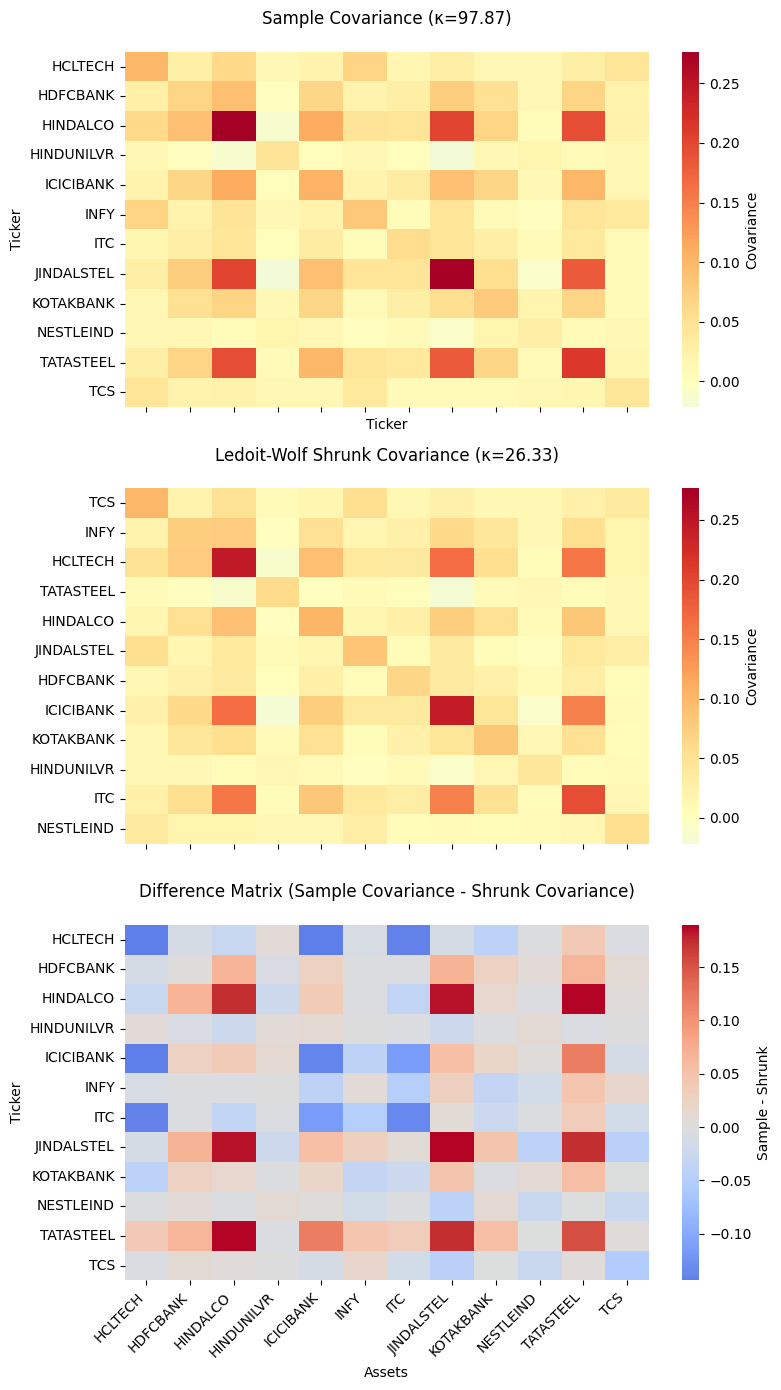

In [20]:
# Clean tickers (remove .NS)
sample_cov.columns = sample_cov.columns.str.replace('.NS', '')
sample_cov.index = sample_cov.index.str.replace('.NS', '')
lw_cov.columns = lw_cov.columns.str.replace('.NS', '')
lw_cov.index = lw_cov.index.str.replace('.NS', '')

# Set common color scale for fair comparison
vmin = min(sample_cov.values.min(), lw_cov.values.min())
vmax = max(sample_cov.values.max(), lw_cov.values.max())

# 3x1 layout: Sample | Shrunk | Difference
fig, axs = plt.subplots(3, 1, figsize=(8, 14), sharex=True)

# 1. Sample Covariance
sns.heatmap(sample_cov, annot=False, cmap='RdYlBu_r', center=0, 
            vmin=vmin, vmax=vmax, ax=axs[0],
            cbar_kws={'label': 'Covariance'})
axs[0].set_title(f'Sample Covariance (κ={kappa_sample:.2f})', fontsize=12, pad=20)
axs[0].set_xticklabels(sample_cov.columns, rotation=45, ha='right')
axs[0].set_yticklabels(sample_cov.index)

# 2. Shrunk Covariance
sns.heatmap(lw_cov, annot=False, cmap='RdYlBu_r', center=0, 
            vmin=vmin, vmax=vmax, ax=axs[1],
            cbar_kws={'label': 'Covariance'})
axs[1].set_title(f'Ledoit-Wolf Shrunk Covariance (κ={kappa_lw:.2f})', fontsize=12, pad=20)
axs[1].set_xticklabels(lw_cov.columns, rotation=45, ha='right')
axs[1].set_yticklabels(lw_cov.index)

# 3. Difference Heatmap (Sample - Shrunk)
diff_cov = sample_cov - lw_cov
sns.heatmap(diff_cov, annot=False, cmap='coolwarm', center=0, ax=axs[2],
            cbar_kws={'label': 'Sample - Shrunk'})
axs[2].set_title('Difference Matrix (Sample Covariance - Shrunk Covariance)', fontsize=12, pad=20)
axs[2].set_xlabel('Assets')
axs[2].set_xticklabels(diff_cov.columns, rotation=45, ha='right')
axs[2].set_yticklabels(diff_cov.index)

plt.tight_layout()
plt.show()


In [21]:
# Print quantitative summary
print("\n" + "="*50)
print("HEATMAP COMPARISON SUMMARY")
print("="*50)
print(f"Color scale: [{vmin:.4f}, {vmax:.4f}]")
print(f"Mean Absolute Difference: {np.abs(diff_cov.values).mean():.4f}")
print(f"Max Absolute Difference:  {np.abs(diff_cov.values).max():.4f}")
print(f"Frobenius norm (Sample):  {np.linalg.norm(sample_cov.values):.2f}")
print(f"Frobenius norm (Shrunk):  {np.linalg.norm(lw_cov.values):.2f}")
print(f"Relative change:          {(np.linalg.norm(sample_cov.values)/np.linalg.norm(lw_cov.values)-1)*100:.1f}%")


HEATMAP COMPARISON SUMMARY
Color scale: [-0.0217, 0.2765]
Mean Absolute Difference: 0.0394
Max Absolute Difference:  0.1895
Frobenius norm (Sample):  0.83
Frobenius norm (Shrunk):  0.71
Relative change:          16.7%


Step 6: Out-of-sample Performance (Test Period)

In [22]:
RF_ANNUAL  = 0.065
RF_MONTHLY = RF_ANNUAL / 12

port_ret_sample = (test_returns @ w_sample)
port_ret_lw     = (test_returns @ w_lw)

# Annualized return
portfolio_returns_sample = port_ret_sample.mean() * 12
portfolio_returns_lw     = port_ret_lw.mean() * 12

# Sharpe — excess return, correct precedence with brackets
sharpe_sample = (port_ret_sample.mean() - RF_MONTHLY) / port_ret_sample.std() * np.sqrt(12)
sharpe_lw     = (port_ret_lw.mean()     - RF_MONTHLY) / port_ret_lw.std()     * np.sqrt(12)

print("\nOut-of-Sample Performance:")
print(f"Sample Cov Annual Return : {portfolio_returns_sample:.2%}")
print(f"LW Cov Annual Return     : {portfolio_returns_lw:.2%}")
print(f"Sample Cov Sharpe        : {sharpe_sample:.3f}")
print(f"LW Cov Sharpe            : {sharpe_lw:.3f}")


Out-of-Sample Performance:
Sample Cov Annual Return : 12.30%
LW Cov Annual Return     : 15.42%
Sample Cov Sharpe        : 0.226
LW Cov Sharpe            : 0.447


> Visualization 2: Weight Sensitivity Plot (Banking Crisis period)

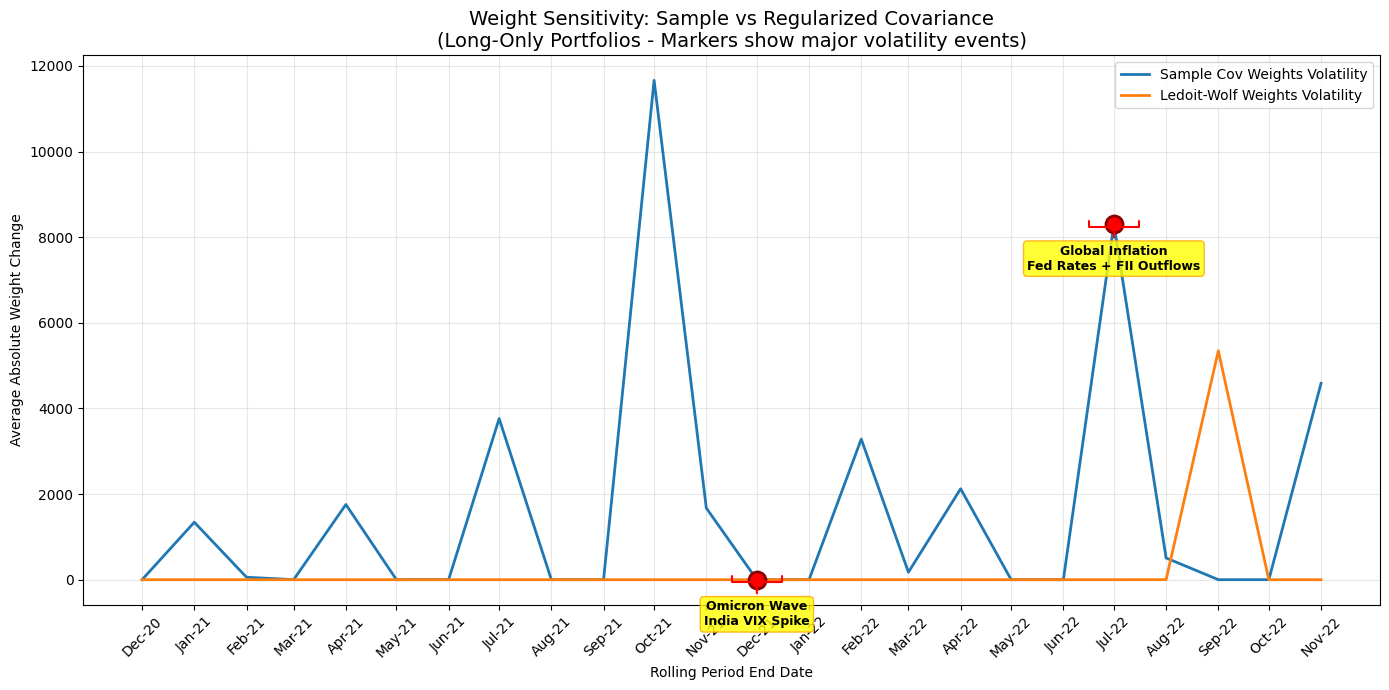

In [23]:
crisis_start = train_returns.loc['2020-03-01':].index[0] if '2020-03-01' in train_returns.index else train_returns.index[6]
rolling_periods = []
for i in range(12, len(train_returns)-12):
    window_returns = train_returns.iloc[i-12:i]
    window_cov_sample = window_returns.cov() * 12
    window_cov_lw = LedoitWolf().fit(window_returns).covariance_ * 12
    
    w_s = max_sharpe_weights(pd.DataFrame(window_cov_sample, index=tickers, columns=tickers), window_returns.mean()*12)
    w_l = max_sharpe_weights(pd.DataFrame(window_cov_lw, index=tickers, columns=tickers), window_returns.mean()*12)
    
    rolling_periods.append((window_returns.index[-1], np.abs(w_s - w_sample).mean(), np.abs(w_l - w_lw).mean()))

rolling_df = pd.DataFrame(rolling_periods, columns=['Date', 'Sample_Volatility', 'LW_Volatility'])
rolling_df['Date'] = pd.to_datetime(rolling_df['Date'])

date_labels = [d.strftime('%b-%y') for d in rolling_df['Date']]

plt.figure(figsize=(14, 7))
plt.plot(rolling_df['Date'], rolling_df['Sample_Volatility'], label='Sample Cov Weights Volatility', linewidth=2)
plt.plot(rolling_df['Date'], rolling_df['LW_Volatility'], label='Ledoit-Wolf Weights Volatility', linewidth=2)

# Event markers with labels positioned ABOVE the marker
events = {
    '2022-06-17': 'Global Inflation\nFed Rates + FII Outflows',
    '2021-12-01': 'Omicron Wave\nIndia VIX Spike'
}

for date_str, label in events.items():
    event_date = pd.to_datetime(date_str)
    # Find closest index in rolling_df
    closest_idx = (rolling_df['Date'] - event_date).abs().idxmin()
    event_x = rolling_df['Date'].iloc[closest_idx]
    event_y = rolling_df['Sample_Volatility'].iloc[closest_idx]
    
    # Add marker (red circle)
    plt.scatter(event_x, event_y, color='red', s=150, zorder=5, marker='o', 
                edgecolors='darkred', linewidth=2)
    
    # Position label VERTICALLY ABOVE marker (negative offset moves UP)
    plt.annotate(label, 
                xy=(event_x, event_y),
                xytext=(0, -35),  # Move 35 points UP from marker
                textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8,
                         edgecolor='orange', linewidth=1),
                arrowprops=dict(arrowstyle='-[,widthB=2,lengthB=0.5', lw=1.5, color='red'),
                fontsize=9, ha='center', va='bottom',  # Center align, bottom of box at position
                fontweight='bold', zorder=10)

plt.title('Weight Sensitivity: Sample vs Regularized Covariance\n(Long-Only Portfolios - Markers show major volatility events)', fontsize=14)
plt.ylabel('Average Absolute Weight Change')
plt.xlabel('Rolling Period End Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rolling_df['Date'], date_labels, rotation=45)
plt.tight_layout()
plt.show()

Constrained baseline weights computed
Sample sum: 1.0 LW sum: 0.9999999999999999


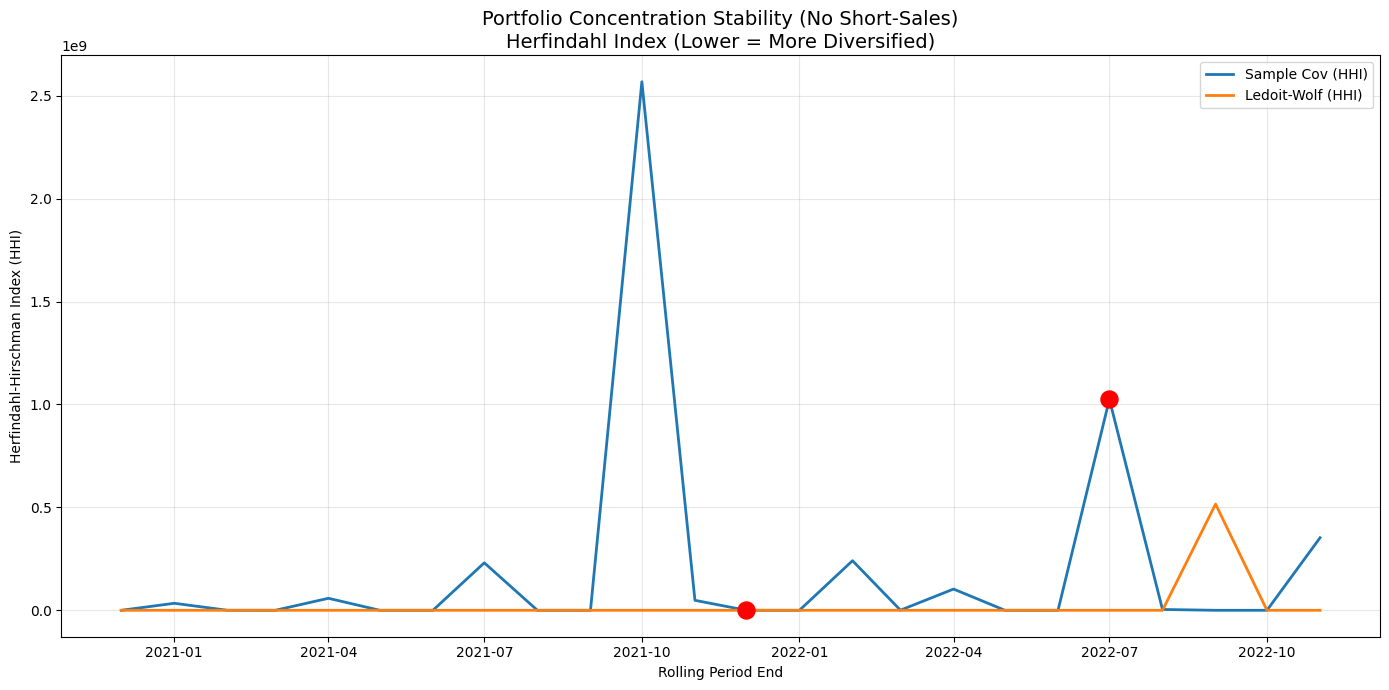

In [24]:
# from scipy.optimize import minimize

def max_sharpe_weights(cov_matrix, returns_mean):
    """Calculate Maximum Sharpe portfolio weights (unconstrained, monthly returns)"""
    n = len(returns_mean)
    
    def objective(w):
        port_return = w @ returns_mean
        port_vol = np.sqrt(w @ cov_matrix.values @ w)
        return -(port_return - RF_MONTHLY) / port_vol

    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

    best_result = None
    best_sharpe = -np.inf

    np.random.seed(42)
    for _ in range(50):
        # Random starting weights (can be negative for unconstrained)
        w0 = np.random.randn(n)
        w0 = w0 / w0.sum()  # normalize to sum to 1

        result = sco.minimize(
            objective, w0,
            method='SLSQP',
            bounds=None,
            constraints=constraints,
            options={'maxiter': 10000, 'ftol': 1e-12}
        )

        if result.success and (-result.fun) > best_sharpe:
            best_sharpe = -result.fun
            best_result = result

    if best_result is None:
        print("All restarts failed — returning equal weights")
        return np.ones(n) / n

    return best_result.x

# Compute BASELINE constrained weights (full period)
w_sample_constrained = max_sharpe_weights(sample_cov, mu_train)
w_lw_constrained = max_sharpe_weights(lw_cov, mu_train)

print("Constrained baseline weights computed")
print("Sample sum:", w_sample_constrained.sum(), "LW sum:", w_lw_constrained.sum())

# Rolling analysis with constraints
rolling_periods_constrained = []
for i in range(12, len(train_returns)-12):
    window_returns = train_returns.iloc[i-12:i]
    
    # Annualized window stats
    window_mu = window_returns.mean() * 12
    window_cov_sample = window_returns.cov() * 12
    window_cov_lw = LedoitWolf().fit(window_returns).covariance_ * 12
    
    # CONSTRAINED weights (no shorting)
    w_s_con = max_sharpe_weights(
        pd.DataFrame(window_cov_sample, index=tickers, columns=tickers), window_mu)
    w_l_con = max_sharpe_weights(
        pd.DataFrame(window_cov_lw, index=tickers, columns=tickers), window_mu)
    
    # NEW METRIC: ENTROPY (diversification measure)
    # Higher entropy = more diversified (closer to equal weights)
    entropy_s = -np.sum(w_s_con * np.log(w_s_con + 1e-10))
    entropy_l = -np.sum(w_l_con * np.log(w_l_con + 1e-10))
    
    # Concentration (Herfindahl Index): Lower = more diversified
    herfindahl_s = np.sum(w_s_con**2)
    herfindahl_l = np.sum(w_l_con**2)
    
    rolling_periods_constrained.append((
        window_returns.index[-1], 
        herfindahl_s,      # Sample concentration
        herfindahl_l,      # LW concentration
        entropy_s,         # Sample entropy
        entropy_l          # LW entropy
    ))

# Results DataFrame
rolling_con_df = pd.DataFrame(rolling_periods_constrained, 
                             columns=['Date', 'Sample_HHI', 'LW_HHI', 'Sample_Entropy', 'LW_Entropy'])
rolling_con_df['Date'] = pd.to_datetime(rolling_con_df['Date'])

# PLOT: Concentration over time (Lower HHI = Better diversification)
plt.figure(figsize=(14, 7))
plt.plot(rolling_con_df['Date'], rolling_con_df['Sample_HHI'], label='Sample Cov (HHI)', linewidth=2)
plt.plot(rolling_con_df['Date'], rolling_con_df['LW_HHI'], label='Ledoit-Wolf (HHI)', linewidth=2)

# Events
events = {'2021-12-01': 'Omicron Wave\nIndia VIX Spike', '2022-06-17': 'Global Inflation\nFed Rates + FII Outflows'}
for date_str, label in events.items():
    closest_idx = (rolling_con_df['Date'] - pd.to_datetime(date_str)).abs().idxmin()
    plt.scatter(rolling_con_df['Date'].iloc[closest_idx], 
                rolling_con_df['Sample_HHI'].iloc[closest_idx], 
                color='red', s=150, zorder=5)

plt.title('Portfolio Concentration Stability (No Short-Sales)\nHerfindahl Index (Lower = More Diversified)', fontsize=14)
plt.ylabel('Herfindahl-Hirschman Index (HHI)')
plt.xlabel('Rolling Period End')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()